In [1]:
import os
import glob
import re
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm as tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from sklearn.cluster import MiniBatchKMeans, SpectralClustering, AffinityPropagation
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer
from sklearn.metrics import silhouette_score, adjusted_rand_score
from itertools import cycle, islice
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter, defaultdict
from scipy.spatial import ConvexHull, QhullError
import plotly.express as px

# ==============================================================================
# 1. SCRIBE IDENTIFICATION FUNCTIONS (Updated Names)
# ==============================================================================

def get_scribe_id_olszowy(filename_folio_part):
    """
    Map a filename's folio part (e.g. '3r', '112v') to one of Judith's 6 scribes.
    UPDATED: Returns 'Olszowy-Schlanger' instead of 'Olszowy'.
    """

    # Parse folio number and side
    folio_num_str = ''.join(filter(str.isdigit, filename_folio_part))
    if not folio_num_str:
        return 'Unknown'

    folio_num = int(folio_num_str)
    side = filename_folio_part[-1].lower()

    # ----------------------------
    # Special cases
    # ----------------------------

    if folio_num == 95 and side == 'r':
        return 'Olszowy-Schlanger 1'

    if folio_num == 95 and side == 'v':
        return 'Olszowy-Schlanger 2'

    if folio_num == 112 and side == 'v':
        return 'Olszowy-Schlanger 6'

    if folio_num == 62 and side == 'v':
        return 'Olszowy-Schlanger 5'

    if folio_num == 154 and side == 'v':
        return 'Olszowy-Schlanger 2'

    # ----------------------------
    # Generic ranges per Judith
    # ----------------------------

    if (2 <= folio_num <= 30) or (64 <= folio_num <= 95) or (113 <= folio_num <= 152):
        return 'Olszowy-Schlanger 1'

    if (31 <= folio_num <= 33) or (50 <= folio_num <= 53) or (96 <= folio_num <= 112) or (153 <= folio_num <= 154):
        return 'Olszowy-Schlanger 2'

    if 34 <= folio_num <= 36:
        return 'Olszowy-Schlanger 3'

    if (37 <= folio_num <= 49) or (folio_num == 63) or (155 <= folio_num <= 226):
        return 'Olszowy-Schlanger 4'

    if 54 <= folio_num <= 62:
        return 'Olszowy-Schlanger 5'

    if folio_num == 112:
        return 'Olszowy-Schlanger 6'

    return 'Unknown'

def get_scribe_id_sfardata(filename_folio_part):
    """
    Map a filename's folio part (e.g. '3r', '95v') to one of Sfardata's 11 scribes.
    """
    # Parse folio number and side
    folio_num_str = ''.join(filter(str.isdigit, filename_folio_part))
    if not folio_num_str:
        return 'Unknown'

    folio_num = int(folio_num_str)
    side = filename_folio_part[-1].lower()

    # Special cases (split folios)
    if folio_num == 95 and side == 'r': return 'Sfardata 9'
    if folio_num == 95 and side == 'v': return 'Sfardata 3'
    if folio_num == 112 and side == 'v': return 'Sfardata 10'
    if folio_num == 62 and side == 'v': return 'Sfardata 7'
    if folio_num == 121 and side == 'v': return 'Sfardata 1'
    if folio_num == 154 and side == 'v': return 'Sfardata 3'

    # Generic ranges
    if (2 <= folio_num <= 5) or (9 <= folio_num <= 30) or (118 <= folio_num <= 121) or (133 <= folio_num <= 152):
        return 'Sfardata 1'
    if 6 <= folio_num <= 8:
        return 'Sfardata 2'
    if (31 <= folio_num <= 33) or (96 <= folio_num <= 112) or (153 <= folio_num <= 154):
        return 'Sfardata 3'
    if 34 <= folio_num <= 36:
        return 'Sfardata 4'
    if (37 <= folio_num <= 49) or (155 <= folio_num <= 226):
        return 'Sfardata 5'
    if 50 <= folio_num <= 53:
        return 'Sfardata 6'
    if 54 <= folio_num <= 62:
        return 'Sfardata 7'
    if folio_num == 63:
        return 'Sfardata 8'
    if (64 <= folio_num <= 94) or (122 <= folio_num <= 132):
        return 'Sfardata 9'
    if folio_num == 112:
        return 'Sfardata 10'
    if 113 <= folio_num <= 117:
        return 'Sfardata 11'

    return 'Unknown'



In [2]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt

# Your folder
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/huntington_dataset"

def extract_folio_side_from_filename(path):
    """
    Example filename:
    'Bodleian-Library-MS-Huntington-200_00009_3r.jpg' -> '3r'
    """
    base = os.path.basename(path)
    name = os.path.splitext(base)[0]
    folio_part = name.split('_')[-1]  # '3r', '4v', etc.
    return folio_part


In [3]:
# ==============================================================================
# 2. DATA LOADING AND DATAFRAME CREATION
# ==============================================================================

# Your folder
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/huntington_dataset"

def extract_folio_side_from_filename(path):
    base = os.path.basename(str(path))
    name = os.path.splitext(base)[0]
    folio_part = name.split('_')[-1]
    return folio_part

# Collect all image paths
image_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.jpg")))

rows = []
for idx, path in enumerate(sorted(image_paths)):
    folio_side = extract_folio_side_from_filename(path)
    folio_num_str = ''.join(filter(str.isdigit, folio_side))
    if folio_num_str == '':
        continue
    folio_num = int(folio_num_str)
    side = folio_side[-1].lower()

    olszowy_label = get_scribe_id_olszowy(folio_side)
    sfardata_label = get_scribe_id_sfardata(folio_side)

    rows.append({
        "seq_idx": idx,
        "image_path": path,
        "folio_side": folio_side,
        "folio_num": folio_num,
        "side": side,
        "Olszowy-Schlanger": olszowy_label, # Renamed column
        "Sfardata": sfardata_label,
    })

df = pd.DataFrame(rows)

# Sort
side_order = {'r': 0, 'v': 1}
df["side_rank"] = df["side"].map(side_order)
df = df.sort_values(by=["folio_num", "side_rank"]).reset_index(drop=True)
df["page_idx"] = df.index

df.head()


,seq_idx,image_path,folio_side,folio_num,side,Olszowy-Schlanger,Sfardata,side_rank,page_idx
0,0,/content/drive/MyDrive/Colab Notebooks/hsd_14_...,3r,3,r,Olszowy-Schlanger 1,Sfardata 1,0,0
1,1,/content/drive/MyDrive/Colab Notebooks/hsd_14_...,3v,3,v,Olszowy-Schlanger 1,Sfardata 1,1,1
2,2,/content/drive/MyDrive/Colab Notebooks/hsd_14_...,4r,4,r,Olszowy-Schlanger 1,Sfardata 1,0,2
3,3,/content/drive/MyDrive/Colab Notebooks/hsd_14_...,4v,4,v,Olszowy-Schlanger 1,Sfardata 1,1,3
4,4,/content/drive/MyDrive/Colab Notebooks/hsd_14_...,5r,5,r,Olszowy-Schlanger 1,Sfardata 1,0,4


Sfardata             Sfardata 1  Sfardata 2  Sfardata 9  Sfardata 11  \
Olszowy-Schlanger                                                      
Olszowy-Schlanger 1          98           6          85           10   
Olszowy-Schlanger 2           0           0           0            0   
Olszowy-Schlanger 3           0           0           0            0   
Olszowy-Schlanger 4           0           0           0            0   
Olszowy-Schlanger 5           0           0           0            0   
Olszowy-Schlanger 6           0           0           0            0   

Sfardata             Sfardata 3  Sfardata 6  Sfardata 4  Sfardata 5  \
Olszowy-Schlanger                                                     
Olszowy-Schlanger 1           0           0           0           0   
Olszowy-Schlanger 2          44           8           0           0   
Olszowy-Schlanger 3           0           0           6           0   
Olszowy-Schlanger 4           0           0           0         169 

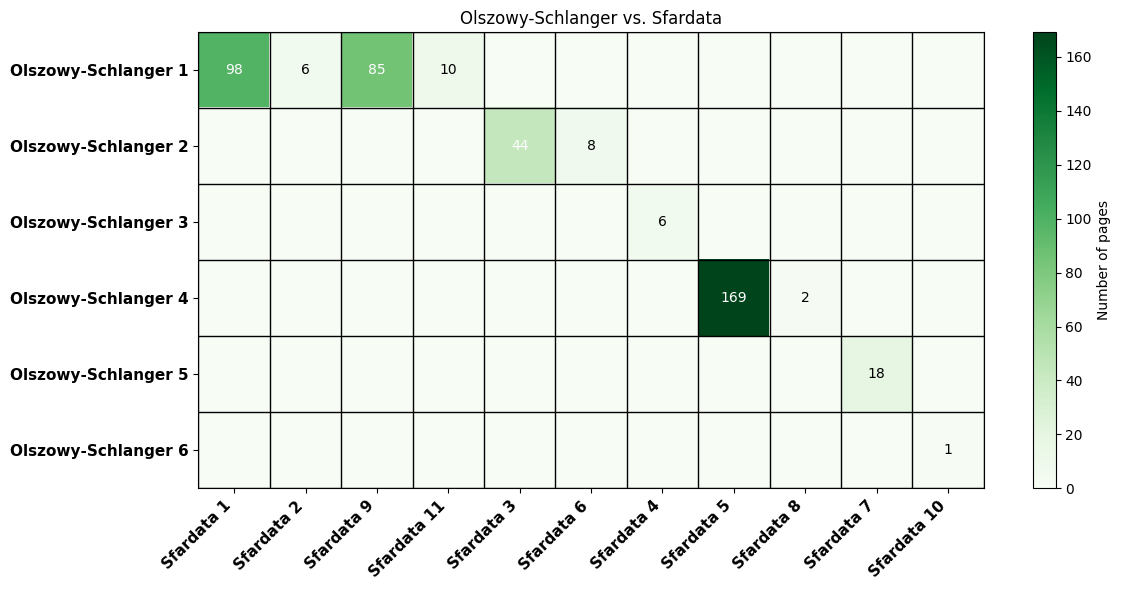

In [62]:
# ==============================================================================
# 3. CONTINGENCY TABLE & HEATMAP (Aligned & Green)
# ==============================================================================
import re

# 1. Create Contingency Table
ct = pd.crosstab(df["Olszowy-Schlanger"], df["Sfardata"])

# --- HELPER: Extract numbers for sorting ---
def get_num(s):
    nums = re.findall(r'\d+', str(s))
    return int(nums[0]) if nums else 999

# 2. Sort Rows (Olszowy) Numerically first
# This ensures Olszowy 1 is top, Olszowy 6 is bottom
sorted_rows = sorted(ct.index, key=get_num)
ct = ct.reindex(sorted_rows)

# 3. Align Columns (Sfardata) to Rows
# Logic: Sort Sfardata columns based on which Olszowy row they have the highest overlap with.
def align_key(col_name):
    # Find which Olszowy scribe is the "winner" for this Sfardata column
    dominant_olszowy = ct[col_name].idxmax()

    # Get the rank of that Olszowy scribe (0, 1, 2...)
    primary_rank = ct.index.get_loc(dominant_olszowy)

    # Secondary sort: Sfardata number (so Sfardata 1 comes before Sfardata 9 if both map to Olszowy 1)
    secondary_rank = get_num(col_name)

    return (primary_rank, secondary_rank)

sorted_cols = sorted(ct.columns, key=align_key)
ct = ct[sorted_cols]

print(ct)

# --- HEATMAP ---
fig, ax = plt.subplots(figsize=(12, 6)) # Slightly wider for 11 columns
data = ct.values

# GREEN colormap
im = ax.imshow(data, aspect='auto', cmap='Greens')

ax.set_xticks(np.arange(len(ct.columns)))
ax.set_yticks(np.arange(len(ct.index)))
ax.set_xticklabels(ct.columns, rotation=45, ha='right')
ax.set_yticklabels(ct.index)

ax.set_title("Olszowy-Schlanger vs. Sfardata")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of pages")

# Annotate with numbers
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if val > 0:
            # White text if dark green, Black text if light
            ax.text(j, i, f"{val}", ha="center", va="center",
                    color="white" if val > 30 else "black", fontsize=10)

# Grid Styling
ax.set_xticks(np.arange(data.shape[1] + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(data.shape[0] + 1) - 0.5, minor=True)

# Black Bold Labels (as requested)
plt.setp(ax.get_xticklabels(), color="black", fontsize=11, fontweight="bold")
plt.setp(ax.get_yticklabels(), color="black", fontsize=11, fontweight="bold")

ax.grid(which='minor', color='black', linestyle='-', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)

plt.tight_layout()
plt.savefig("olszowy_sfardata_heatmap_aligned.png", dpi=300, bbox_inches='tight')
plt.show()

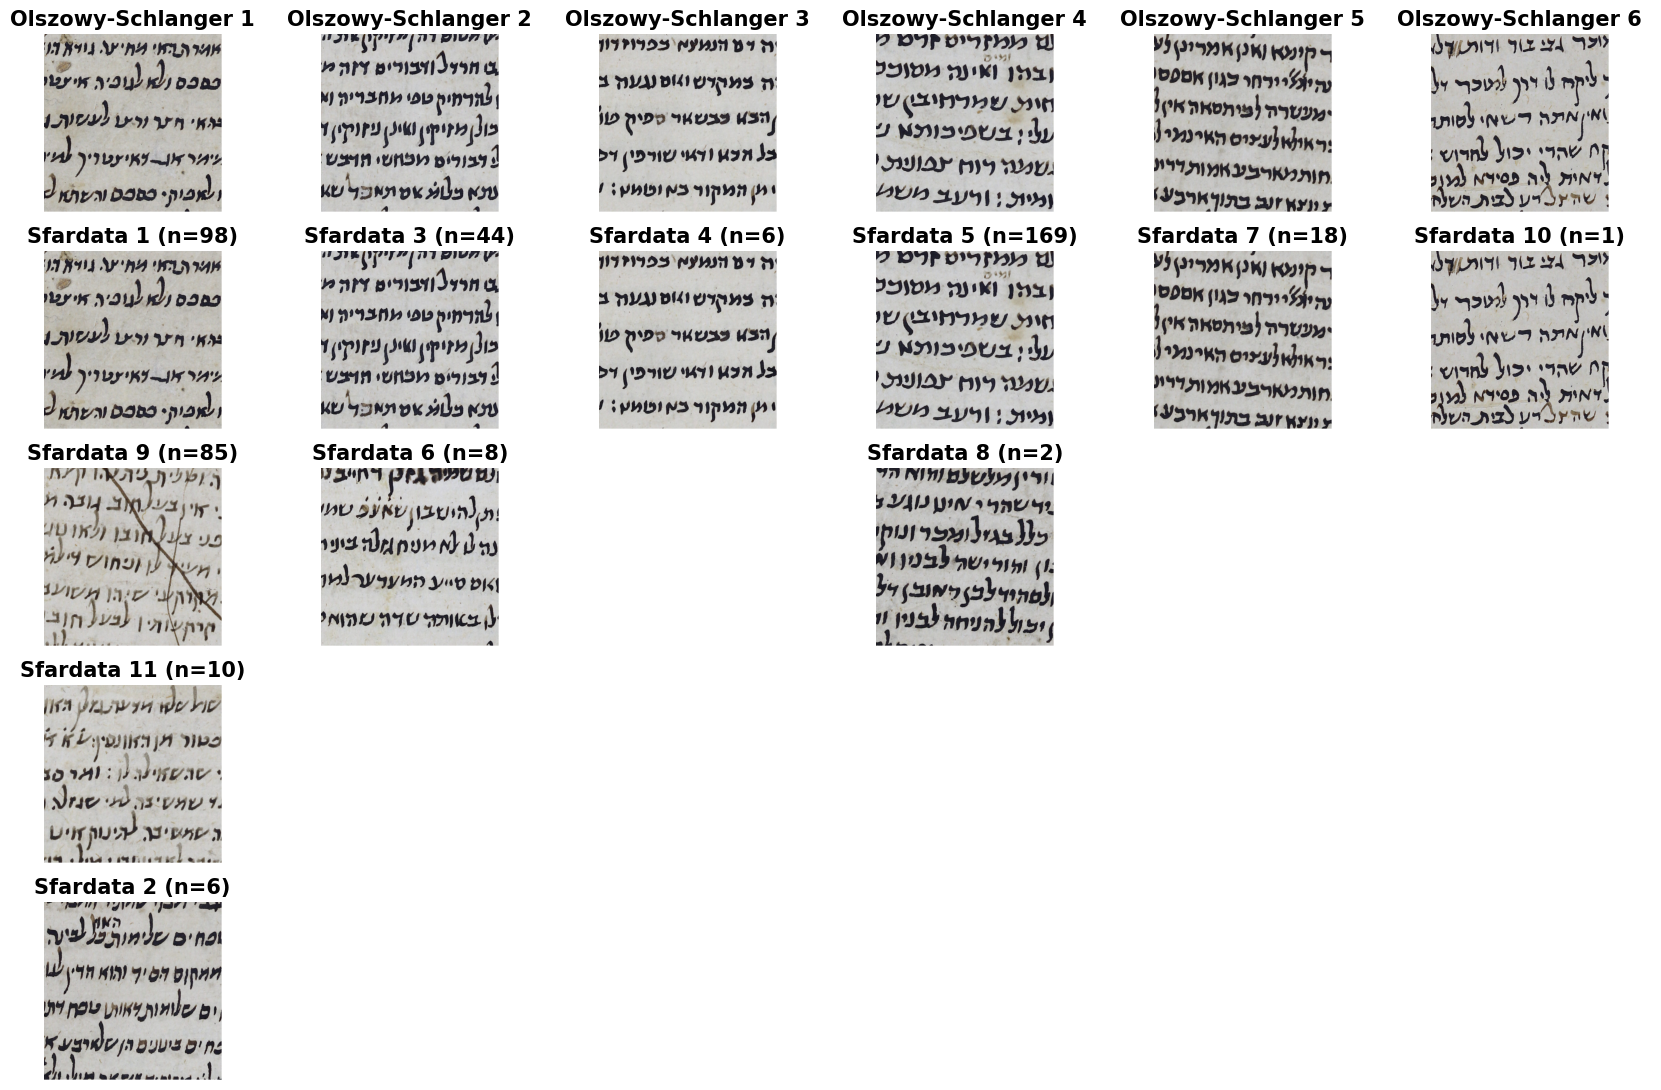

In [39]:
 # ==============================================================================
# 4. CROP GRID VISUALIZATION
# ==============================================================================

CROP_SIZE = 501
if "image_path" in df.columns:
    df["file_path"] = df["image_path"]

def central_crop_rgb(img_bgr, size=100):
    if img_bgr is None: return None
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    half = size // 2
    cy, cx = h // 2, w // 2
    y0, y1 = max(0, cy - half), min(h, cy + half)
    x0, x1 = max(0, cx - half), min(w, cx + half)
    crop = img[y0:y1, x0:x1]
    if crop.shape[0] != size or crop.shape[1] != size:
        pad_y = size - crop.shape[0]
        pad_x = size - crop.shape[1]
        crop = cv2.copyMakeBorder(crop, 0, pad_y, 0, pad_x, cv2.BORDER_CONSTANT, value=[255,255,255])
    return crop

def pick_path_for_label(df, label_col, label_value):
    sub = df[df[label_col] == label_value]
    if len(sub) == 0: return None
    return sub.iloc[0]["file_path"]

# Updated Labels
olszowy_labels = [f"Olszowy-Schlanger {i}" for i in range(1, 7)]

ols_to_sf_list = {}
max_sf_per_ols = 0

for ols in olszowy_labels:
    # Updated column reference
    counts = df[df["Olszowy-Schlanger"] == ols]["Sfardata"].value_counts()
    sf_list = [(sf, int(cnt)) for sf, cnt in counts.items()]
    ols_to_sf_list[ols] = sf_list
    max_sf_per_ols = max(max_sf_per_ols, len(sf_list))

nrows = 1 + max_sf_per_ols
ncols = 6
fig, axes = plt.subplots(nrows, ncols, figsize=(2.8*ncols, 2.2*nrows))
if nrows == 1: axes = np.array([axes])

for ax in axes.ravel(): ax.axis("off")

# Row 0: Olszowy crops
for j, ols in enumerate(olszowy_labels):
    ax = axes[0, j]
    p = pick_path_for_label(df, "Olszowy-Schlanger", ols)
    crop = None if p is None else central_crop_rgb(cv2.imread(p), CROP_SIZE)
    if crop is None: ax.text(0.5, 0.5, "Missing", ha="center", va="center")
    else: ax.imshow(crop)
    ax.set_title(ols, fontsize=15, fontweight="bold")
    ax.axis("off")

# Rows 1..: Corresponding Sfardata
for j, ols in enumerate(olszowy_labels):
    sf_list = ols_to_sf_list.get(ols, [])
    for i, (sf, cnt) in enumerate(sf_list):
        ax = axes[i+1, j]
        p = pick_path_for_label(df, "Sfardata", sf)
        crop = None if p is None else central_crop_rgb(cv2.imread(p), CROP_SIZE)
        if crop is None: ax.text(0.5, 0.5, "Missing", ha="center", va="center")
        else: ax.imshow(crop)
        ax.set_title(f"{sf} (n={cnt})", fontsize=15, fontweight="bold")
        ax.axis("off")

plt.tight_layout()
plt.savefig("olszowy_top_sfardata_under_each.png", dpi=300, bbox_inches="tight")
plt.show()

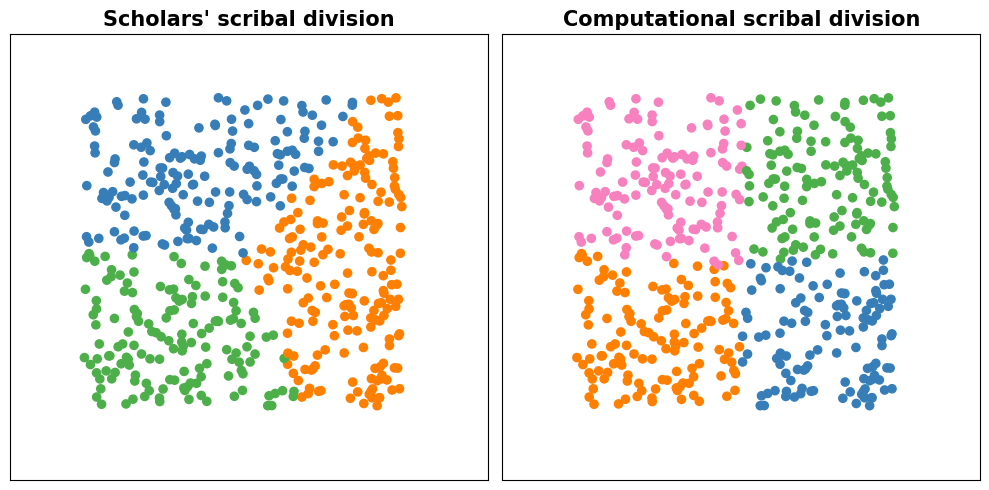

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

# 1. Setup Data (Last Row: No Structure)
n_samples = 500
seed = 30
rng = np.random.RandomState(seed)
# Generate random uniform noise
X = rng.rand(n_samples, 2)
# Standardize features as done in the example
X = StandardScaler().fit_transform(X)

# 2. Setup Algorithms
# Parameters taken from 'default_base' in the example source code
params = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 3,
    "n_clusters": 3,
    "min_samples": 7,
    "xi": 0.05,
    "min_cluster_size": 0.1,
    "random_state": 42,
}

# Algorithm 1 (First Column): MiniBatch KMeans
minibatch_kmeans = cluster.MiniBatchKMeans(
    n_clusters=params["n_clusters"],
    random_state=params["random_state"]
)

# Algorithm 2 (Second Column): Affinity Propagation
affinity_propagation = cluster.AffinityPropagation(
    damping=params["damping"],
    preference=params["preference"],
    random_state=params["random_state"]
)

algorithms = [
    ("Scholars' scribal division", minibatch_kmeans),
    ("Computational scribal division", affinity_propagation)
]

# 3. Plotting
plt.figure(figsize=(10, 5))
plt.subplots_adjust(left=.02, right=.98, bottom=.001, top=.96, wspace=.05, hspace=.01)

# Define color cycle used in the example
colors_pool = np.array([
    "#377eb8", "#ff7f00", "#4daf4a", "#f781bf", "#a65628",
    "#984ea3", "#999999", "#e41a1c", "#dede00"
])

for i, (name, algorithm) in enumerate(algorithms):
    # Fit algorithm
    algorithm.fit(X)

    # Get labels
    if hasattr(algorithm, "labels_"):
        y_pred = algorithm.labels_.astype(int)
    else:
        y_pred = algorithm.predict(X)

    # Assign colors
    # The example code logic for colors:
    colors = np.array(list(islice(cycle(colors_pool), int(max(y_pred) + 1))))
    # Add black for outliers if necessary (though these specific algos likely won't produce -1 here)
    colors = np.append(colors, ["#000000"])

    # Create subplot
    plt.subplot(1, 2, i + 1)
    plt.title(name, size=15, fontweight='bold')
    plt.scatter(X[:, 0], X[:, 1], s=35, color=colors[y_pred])

    # Format axes similar to example
    plt.xlim(-2.5, 2.5)
    plt.ylim(-2.5, 2.5)
    plt.xticks(())
    plt.yticks(())
plt.tight_layout()
plt.savefig("scribal_vs_computational_scribal_divisions.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# ==============================================================================
# 6. SETUP, CLASSES, AND HELPER FUNCTIONS FOR DEEP LEARNING
# ==============================================================================

# --- Scribe Colors (FIXED GREEN ISSUE) ---
# Olszowy 1  →  Sfardata 1
# Olszowy 2  →  Sfardata 3
# Olszowy 3  →  Sfardata 4
# Olszowy 4  →  Sfardata 5
# Olszowy 5  →  Sfardata 7
# Olszowy 6  →  Sfardata 10
# Changed 'green' to 'gold' for Scribe 3 to avoid collision with Red (Scribe 1)
SCRIBE_COLORS = {
    'Unknown': 'lightgray',
    # Olszowy-Schlanger (Updated Names)
    'Olszowy-Schlanger 1': 'red',
    'Olszowy-Schlanger 2': 'magenta',
    'Olszowy-Schlanger 3': 'orange',
    'Olszowy-Schlanger 4': 'blue',
    'Olszowy-Schlanger 5': 'purple',
    'Olszowy-Schlanger 6': 'yellow',
    # Sfardata
    'Sfardata 1': 'red',
    'Sfardata 2': 'darkkhaki',
    'Sfardata 3': 'magenta',
    'Sfardata 4': 'orange',
    'Sfardata 5': 'blue',
    'Sfardata 6': 'darkcyan',
    'Sfardata 7': 'purple',
    'Sfardata 8': 'mediumorchid',
    'Sfardata 9': 'slategrey',
    'Sfardata 10': 'yellow',
    'Sfardata 11': 'cyan'
}

# --- Settings ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/trained_sae_model.pth"
OUTPUT_DIR = os.path.dirname(MODEL_SAVE_PATH)
if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)

# --- Classes & Functions (CAE, etc) ---
class CAE(nn.Module):
    def __init__(self, latent_dim):
        super(CAE, self).__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(True), nn.MaxPool2d(2, 2)
        )
        self.encoder_linear = nn.Sequential(nn.Flatten(), nn.Linear(64 * 8 * 8, latent_dim))
        self.decoder_linear = nn.Sequential(nn.Linear(latent_dim, 64 * 8 * 8), nn.ReLU(True))
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),   nn.ReLU(True),
            nn.Conv2d(16, 1, kernel_size=3, padding=1), nn.Sigmoid()
        )
    def encode(self, x):
        x = self.encoder_conv(x)
        return self.encoder_linear(x)
    def forward(self, x):
        z = self.encode(x)
        x = self.decoder_linear(z)
        return self.decoder_conv(x.view(-1, 64, 8, 8)), z

# --- Core Functions ---
def extract_component_patches(image_path_str, n_components=400):
    img = cv2.imread(image_path_str, cv2.IMREAD_GRAYSCALE)
    if img is None: return [], []
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    valid_components = []
    for i in range(1, num_labels):
        w, h = stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        if 20 < h < 100 and w >= 10:
            valid_components.append((i, stats[i]))
    if len(valid_components) > n_components:
        valid_components = sorted(valid_components, key=lambda t: t[1][cv2.CC_STAT_AREA], reverse=True)[:n_components]

    component_patches = []
    component_data = []
    for label_id, stat in valid_components:
        x, y, w, h = stat[cv2.CC_STAT_LEFT], stat[cv2.CC_STAT_TOP], stat[cv2.CC_STAT_WIDTH], stat[cv2.CC_STAT_HEIGHT]
        component_mask = (labels[y:y+h, x:x+w] == label_id).astype(np.uint8) * 255
        max_dim = max(w, h)
        padded_component = np.zeros((max_dim, max_dim), dtype=np.uint8)
        start_x, start_y = (max_dim - w) // 2, (max_dim - h) // 2
        padded_component[start_y:start_y + h, start_x:start_x + w] = component_mask
        resized_patch = cv2.resize(padded_component, (PATCH_SIZE, PATCH_SIZE), interpolation=cv2.INTER_AREA)
        component_patches.append(resized_patch)
        component_data.append({'des': None, 'bbox': (x, y, w, h), 'label_id': label_id})
    return component_patches, component_data

def collect_all_patches_and_data(image_files, n_components):
    global ALL_COMPONENT_DATA
    all_patches = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(extract_component_patches, str(path), n_components): path for path in image_files}
        for future in tqdm(as_completed(futures), total=len(image_files), desc="Extracting Patches"):
            path = futures[future]
            try:
                patches, data = future.result()
                all_patches.extend(patches)
                ALL_COMPONENT_DATA[str(path)] = data
            except: pass
    return np.array(all_patches, dtype='uint8') if all_patches else None



In [8]:
# ==============================================================================
# CELL: RESTORE STATE (LOAD MODEL & RE-SCAN DATA)
# ==============================================================================
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm
from sklearn.cluster import MiniBatchKMeans

# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
# ⭐ PATHS (Updated) ⭐
DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/huntington_dataset"
MODEL_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/trained_sae_model.pth"

# Derive an output directory for figures based on the model path
OUTPUT_DIR = os.path.dirname(MODEL_SAVE_PATH)
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
print(f"Model and Figures will be saved to: {OUTPUT_DIR}")


# Hyperparameters (Must match training!)
PATCH_SIZE = 64
AE_LATENT_DIM = 64
N_COMPONENTS_OPTIMIZED = 400
VOCAB_SIZE = 1000
SEED = 42

# --- 1. Define the Model Architecture (Required to load weights) ---
class CAE(nn.Module):
    def __init__(self, latent_dim):
        super(CAE, self).__init__()
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(True), nn.MaxPool2d(2, 2)
        )
        self.encoder_linear = nn.Sequential(nn.Flatten(), nn.Linear(64 * 8 * 8, latent_dim))
        self.decoder_linear = nn.Sequential(nn.Linear(latent_dim, 64 * 8 * 8), nn.ReLU(True))
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 64, kernel_size=3, stride=2, padding=1, output_padding=1), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  nn.ReLU(True),
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),   nn.ReLU(True),
            nn.Conv2d(16, 1, kernel_size=3, padding=1), nn.Sigmoid()
        )
    def encode(self, x):
        x = self.encoder_conv(x)
        return self.encoder_linear(x)
    def forward(self, x):
        z = self.encode(x)
        x = self.decoder_linear(z)
        return self.decoder_conv(x.view(-1, 64, 8, 8)), z

# --- 2. Load the Saved Model ---
print(f"Loading model from: {MODEL_SAVE_PATH}")
cae_model = CAE(AE_LATENT_DIM).to(DEVICE)
# Load weights (handle mapping if you switched from GPU to CPU)
cae_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
cae_model.eval()
print("✅ Model loaded successfully.")

# --- 3. Define Data Extraction Functions ---
ALL_COMPONENT_DATA = {}

def extract_component_patches(image_path_str, n_components=400):
    img = cv2.imread(image_path_str, cv2.IMREAD_GRAYSCALE)
    if img is None: return [], []
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    valid_components = []
    for i in range(1, num_labels):
        w, h = stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        if 20 < h < 100 and w >= 10:
            valid_components.append((i, stats[i]))
    if len(valid_components) > n_components:
        valid_components = sorted(valid_components, key=lambda t: t[1][cv2.CC_STAT_AREA], reverse=True)[:n_components]

    component_data = []
    # We don't strictly need to return patches array here for BoVW,
    # but we populate ALL_COMPONENT_DATA for the next cell
    for label_id, stat in valid_components:
        x, y, w, h = stat[cv2.CC_STAT_LEFT], stat[cv2.CC_STAT_TOP], stat[cv2.CC_STAT_WIDTH], stat[cv2.CC_STAT_HEIGHT]
        component_data.append({'des': None, 'bbox': (x, y, w, h), 'label_id': label_id})
    return [], component_data

def collect_data(image_files, n_components):
    global ALL_COMPONENT_DATA
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(extract_component_patches, str(path), n_components): path for path in image_files}
        for future in tqdm(as_completed(futures), total=len(image_files), desc="Re-scanning Images"):
            path = futures[future]
            try:
                _, data = future.result()
                ALL_COMPONENT_DATA[str(path)] = data
            except: pass

# --- 4. Execute Data Loading ---
dataset_path = Path(DATASET_PATH)
image_files = sorted(list(dataset_path.glob("*.jpg")) + list(dataset_path.glob("*.png")) + list(dataset_path.glob("*.tif")) + list(dataset_path.glob("*.jpeg")))

if len(image_files) > 0:
    print(f"Found {len(image_files)} images. Re-scanning to populate component data...")
    collect_data(image_files, N_COMPONENTS_OPTIMIZED)
    print("✅ Data ready.")
else:
    print("❌ No images found. Check DATASET_PATH.")

Using device: cpu
Model and Figures will be saved to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025
Loading model from: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/trained_sae_model.pth
✅ Model loaded successfully.
Found 447 images. Re-scanning to populate component data...


Re-scanning Images:   0%|          | 0/447 [00:00<?, ?it/s]

✅ Data ready.


In [9]:
# ==============================================================================
# CELL 4: FEATURE EXTRACTION AND BoVW (CORRECTED)
# ==============================================================================
print("\n--- 3. Extracting Features & Building BoVW ---")

# Initialize the global list to store metadata for visualization
global_descriptors_list = []

def get_latent_vectors(model):
    global global_descriptors_list
    global_descriptors_list = [] # Reset list
    descriptors = []

    model.eval()

    # Iterate through all images and their components
    for path_str, components in tqdm(ALL_COMPONENT_DATA.items(), desc="Encoding Patches"):
        img = cv2.imread(path_str, cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        # Re-calculate connected components to get masks
        _, labels, stats, _ = cv2.connectedComponentsWithStats(
            cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1],
            connectivity=8
        )

        for comp in components:
            x, y, w, h = comp['bbox']
            label_id = comp['label_id']

            # Reconstruct the specific patch from the mask
            mask = (labels[y:y+h, x:x+w] == label_id).astype(np.uint8) * 255
            max_d = max(w, h)
            pad = np.zeros((max_d, max_d), dtype=np.uint8)
            sx, sy = (max_d-w)//2, (max_d-h)//2
            pad[sy:sy+h, sx:sx+w] = mask
            patch = cv2.resize(pad, (PATCH_SIZE, PATCH_SIZE), interpolation=cv2.INTER_AREA)

            # Prepare tensor
            t_patch = torch.from_numpy(patch).float().unsqueeze(0).unsqueeze(0).to(DEVICE) / 255.0

            with torch.no_grad():
                vec = model.encode(t_patch).cpu().numpy().flatten()

            if vec.size == AE_LATENT_DIM:
                comp['des'] = vec
                descriptors.append(vec)

                # --- THIS WAS MISSING ---
                # Save metadata so we can visualize this patch later
                global_descriptors_list.append({
                    'path': path_str,
                    'bbox': comp['bbox'],
                    'des': vec
                })
                # ------------------------

    return np.array(descriptors, dtype=np.float32)

if cae_model:
    # 1. Get Descriptors (and populate global_descriptors_list)
    all_descriptors = get_latent_vectors(cae_model)
    print(f"Extracted {len(all_descriptors)} feature vectors.")

    # 2. Train KMeans
    print("Training K-Means Vocabulary...")
    kmeans_model = MiniBatchKMeans(n_clusters=VOCAB_SIZE, random_state=SEED, n_init='auto', verbose=False)
    kmeans_model.fit(all_descriptors)

    # 3. Build BoVW Vectors
    print("Creating BoVW Histograms...")
    bovw_vectors = []
    for path in tqdm(image_files, desc="BoVW"):
        comps = ALL_COMPONENT_DATA.get(str(path))
        if not comps:
            bovw_vectors.append(np.zeros(VOCAB_SIZE))
            continue
        descs = np.array([c['des'] for c in comps if c.get('des') is not None])
        if descs.size == 0:
            bovw_vectors.append(np.zeros(VOCAB_SIZE))
        else:
            words = kmeans_model.predict(descs.astype(np.float32))
            hist, _ = np.histogram(words, bins=np.arange(VOCAB_SIZE + 1))
            bovw_vectors.append(hist)

    bovw_matrix = np.array(bovw_vectors, dtype=np.float32)
    print(f"BoVW Matrix Shape: {bovw_matrix.shape}")


--- 3. Extracting Features & Building BoVW ---


Encoding Patches:   0%|          | 0/447 [00:00<?, ?it/s]

Extracted 178794 feature vectors.
Training K-Means Vocabulary...
Creating BoVW Histograms...


BoVW:   0%|          | 0/447 [00:00<?, ?it/s]

BoVW Matrix Shape: (447, 1000)



--- Visualizing Examples of Visual Words ---
Mapping all patches to their nearest visual word...
Generating grid for 8 random visual words...


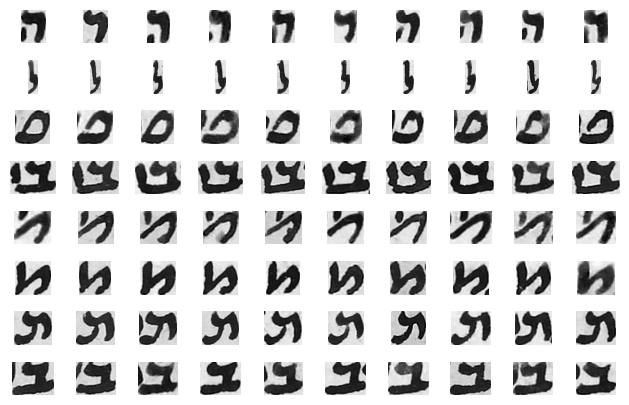

✅ Visual Words plot saved to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/visual_words_examples.png


In [11]:
# ==============================================================================
# CELL 5: VISUALIZING THE "VISUAL WORDS" (THE VOCABULARY)
# ==============================================================================
print("\n--- Visualizing Examples of Visual Words ---")

def visualize_visual_words(kmeans_model, global_descriptors, n_clusters_to_show=5, n_examples=10):
    """
    Selects random clusters and displays the top N patches closest to the cluster center.
    """
    # 1. Get all descriptors and their metadata
    # Ensure global_descriptors_list was populated in previous steps
    if not global_descriptors:
        print("❌ Global descriptor list is empty. Run Feature Extraction first.")
        return

    print("Mapping all patches to their nearest visual word...")

    # Convert list of dicts to array of descriptors for faster processing
    all_descs = np.array([item['des'] for item in global_descriptors])

    # Get the cluster labels for every single patch in the dataset
    labels = kmeans_model.predict(all_descs)

    # Calculate distance of every patch to its assigned cluster center
    # transform() returns distance to ALL centers, we need dist to ASSIGNED center
    all_dists = kmeans_model.transform(all_descs)

    # Pick random clusters to visualize (or pick specific indices if you want)
    cluster_indices = np.random.choice(kmeans_model.n_clusters, n_clusters_to_show, replace=False)

    # Setup Plot
    fig, axes = plt.subplots(n_clusters_to_show, n_examples, figsize=(8, 5))
    plt.subplots_adjust(hspace=0.5, wspace=0.1)

    print(f"Generating grid for {n_clusters_to_show} random visual words...")

    for row_idx, cluster_id in enumerate(cluster_indices):
        # Find all patches belonging to this cluster
        indices_in_cluster = np.where(labels == cluster_id)[0]

        # Get their distances to this specific cluster center
        dists_to_center = all_dists[indices_in_cluster, cluster_id]

        # Sort by distance (smallest distance = best representative)
        sorted_args = np.argsort(dists_to_center)
        best_indices = indices_in_cluster[sorted_args[:n_examples]]

        # Display the patches
        for col_idx, patch_global_idx in enumerate(best_indices):
            ax = axes[row_idx, col_idx]

            # Retrieve metadata to re-load the image patch
            meta = global_descriptors[patch_global_idx]
            path = meta['path']
            x, y, w, h = meta['bbox']

            # Load and Crop
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                patch = img[y:y+h, x:x+w]
                # Invert for better visibility (Black text on White bg)
                # patch = cv2.bitwise_not(patch)
                ax.imshow(patch, cmap='gray')

            ax.axis('off')

        # Label the row
        axes[row_idx, 0].set_ylabel(f"Word {cluster_id}", rotation=0, labelpad=40, fontsize=12, fontweight='bold')

    # Save
    save_path = os.path.join(OUTPUT_DIR, "visual_words_examples.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"✅ Visual Words plot saved to: {save_path}")

# Run the function
# We use the global_descriptors_list that was populated in 'extract_latent_vectors'
visualize_visual_words(kmeans_model, global_descriptors_list, n_clusters_to_show=8, n_examples=10)

--- Generating 3D PCA Plot ---


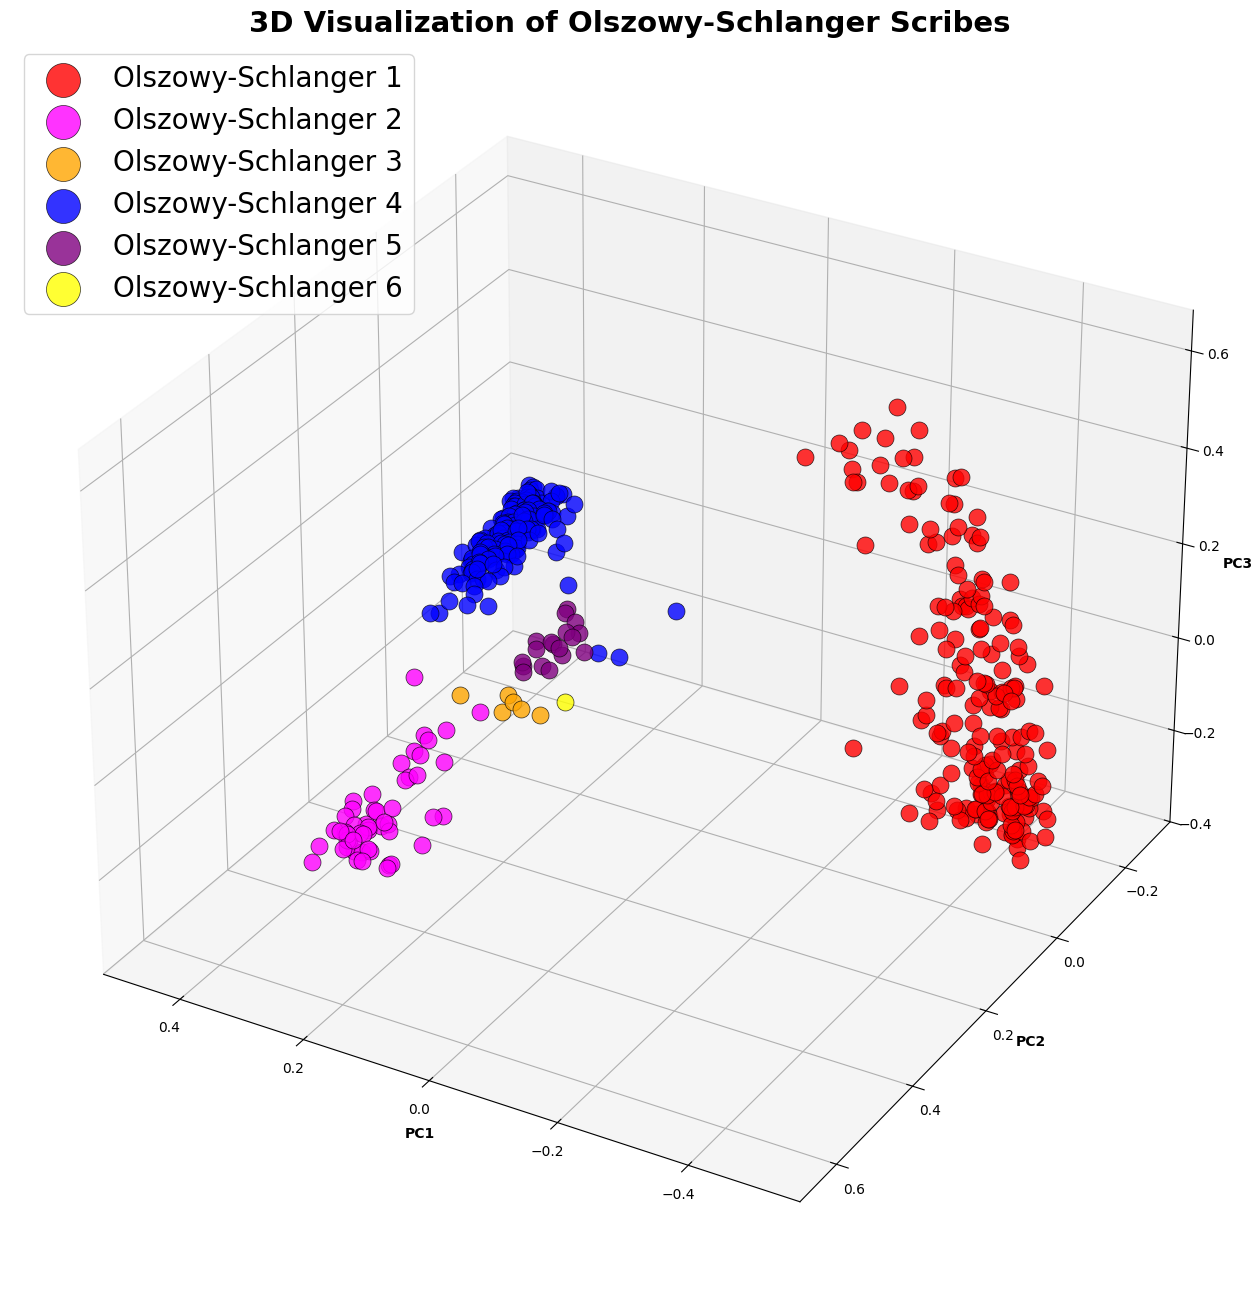

In [46]:
# ==============================================================================
# 8. 3D PCA VISUALIZATION (Olszowy-Schlanger)
# ==============================================================================

print("--- Generating 3D PCA Plot ---")
norm_data = Normalizer(norm='l2').fit_transform(bovw_matrix)
pca_3d = PCA(n_components=3, random_state=SEED)
pca_res_3d = pca_3d.fit_transform(norm_data)

fig = plt.figure(figsize=(15, 13))
ax = fig.add_subplot(111, projection='3d')

for i, fpath in enumerate(image_files):
    folio = extract_folio_side_from_filename(str(fpath))
    scribe_id = get_scribe_id_olszowy(folio) # Returns "Olszowy-Schlanger X"

    if scribe_id == 'Unknown': continue
    color = SCRIBE_COLORS.get(scribe_id, 'gray')

    ax.scatter(pca_res_3d[i, 0], pca_res_3d[i, 1], pca_res_3d[i, 2],
               c=color, label=scribe_id, s=150, edgecolors='k', linewidth=0.5, alpha=0.8)

ax.set_xlabel("PC1", fontweight='bold'); ax.set_ylabel("PC2", fontweight='bold'); ax.set_zlabel("PC3", fontweight='bold')
ax.set_title("3D Visualization of Olszowy-Schlanger Scribes", fontweight='bold', fontsize=21)

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
sorted_keys = sorted(by_label.keys())
ax.legend([by_label[k] for k in sorted_keys], sorted_keys, loc='upper left', fontsize=20, markerscale=2.0)
ax.view_init(elev=30, azim=120)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "3d_pca_plot_olszowy.png"), dpi=300)
plt.show()

In [58]:
# ==============================================================================
# CELL: INTERACTIVE 3D VISUALIZATION (Plotly) - BIG LEGEND
# ==============================================================================
import plotly.express as px
import pandas as pd
import matplotlib.colors as mcolors
import os

print("--- Generating Interactive 3D Plot (Plotly) ---")

# 1. Prepare Data
norm_data = Normalizer(norm='l2').fit_transform(bovw_matrix)
pca_3d = PCA(n_components=3, random_state=SEED)
pca_res_3d = pca_3d.fit_transform(norm_data)

# 2. Build DataFrame
data_rows = []
for i, fpath in enumerate(image_files):
    folio = extract_folio_side_from_filename(str(fpath))
    scribe_id = get_scribe_id_olszowy(folio) # Returns "Olszowy-Schlanger X"

    if scribe_id == 'Unknown':
        continue

    data_rows.append({
        'PC1': pca_res_3d[i, 0],
        'PC2': pca_res_3d[i, 1],
        'PC3': pca_res_3d[i, 2],
        'Scribe': scribe_id,
        'Folio': folio
    })

df_3d = pd.DataFrame(data_rows)
df_3d.sort_values(by='Scribe', inplace=True)

# 3. Map Colors
plotly_color_map = {}
for scribe_name in df_3d['Scribe'].unique():
    if scribe_name in SCRIBE_COLORS:
        plotly_color_map[scribe_name] = mcolors.to_hex(SCRIBE_COLORS[scribe_name])
    else:
        plotly_color_map[scribe_name] = '#808080'

# 4. Generate Plot
fig = px.scatter_3d(
    df_3d,
    x='PC1', y='PC2', z='PC3',
    color='Scribe',
    color_discrete_map=plotly_color_map,
    hover_name='Folio',
    title="Interactive 3D Space: Olszowy-Schlanger Scribes",
    opacity=0.8,
    hover_data={
        'PC1': False,
        'PC2': False,
        'PC3': False,
        'Scribe': True
    }
)

# 5. Styling (Increased Font & Legend Visibility)
fig.update_traces(marker=dict(size=6, line=dict(width=1, color='DarkSlateGrey')))

fig.update_layout(
    width=1200,
    height=900,
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3',
        bgcolor='white'
    ),
    # --- LEGEND STYLING HERE ---
    legend=dict(
        title_font_family="Arial",
        font=dict(size=20),   # Legend Text Size
        itemsizing='constant' # Makes legend dots bigger/consistent
    ),
    legend_title=dict(font=dict(size=22)), # Legend Title Size
)

# 6. Save and Show
output_html = os.path.join(OUTPUT_DIR, "interactive_3d_olszowy.html")
fig.write_html(output_html)
print(f"✅ Interactive plot saved to: {output_html}")

fig.show()

--- Generating Interactive 3D Plot (Plotly) ---
✅ Interactive plot saved to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/interactive_3d_olszowy.html


--- Generating 3D PCA Plot ---


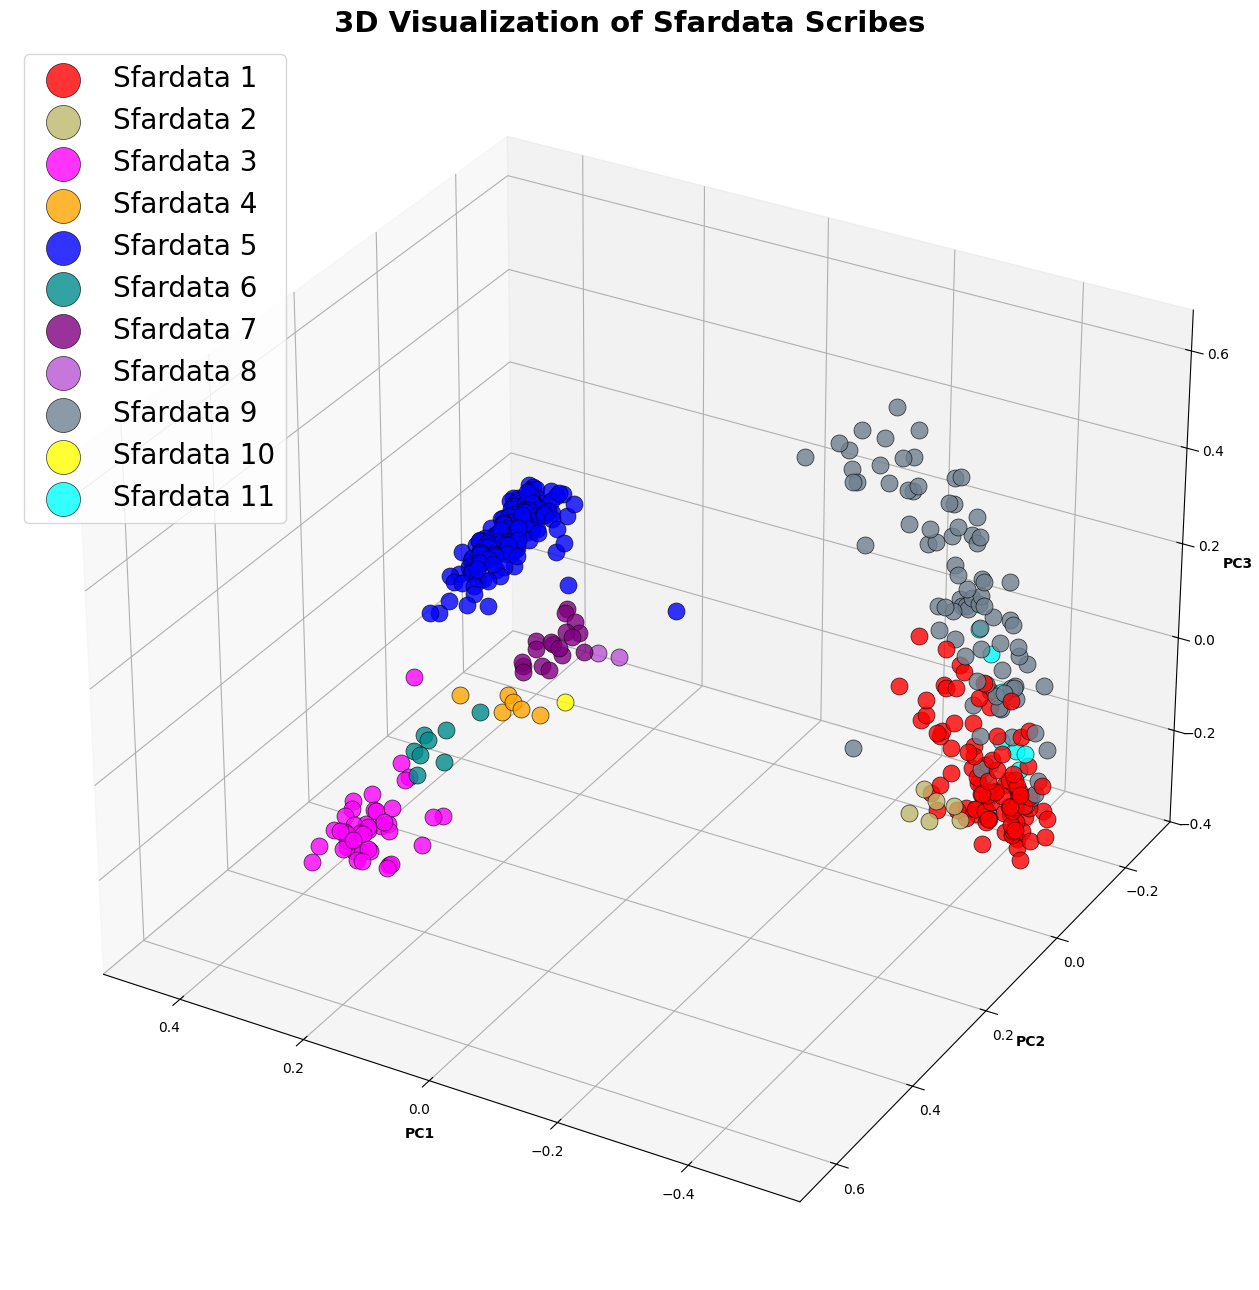

In [48]:
# ==============================================================================
# 8. 3D PCA VISUALIZATION (Sfardata)
# ==============================================================================
import re  # Ensure re is imported

print("--- Generating 3D PCA Plot ---")
norm_data = Normalizer(norm='l2').fit_transform(bovw_matrix)
pca_3d = PCA(n_components=3, random_state=SEED)
pca_res_3d = pca_3d.fit_transform(norm_data)

fig = plt.figure(figsize=(15, 13))
ax = fig.add_subplot(111, projection='3d')

for i, fpath in enumerate(image_files):
    folio = extract_folio_side_from_filename(str(fpath))
    scribe_id = get_scribe_id_sfardata(folio)

    if scribe_id == 'Unknown': continue
    color = SCRIBE_COLORS.get(scribe_id, 'gray')

    ax.scatter(pca_res_3d[i, 0], pca_res_3d[i, 1], pca_res_3d[i, 2],
               c=color, label=scribe_id, s=150, edgecolors='k', linewidth=0.5, alpha=0.8)

ax.set_xlabel("PC1", fontweight='bold'); ax.set_ylabel("PC2", fontweight='bold'); ax.set_zlabel("PC3", fontweight='bold')
ax.set_title("3D Visualization of Sfardata Scribes", fontweight='bold', fontsize=21)

# --- FIX: Custom Sorting Logic ---
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

def numeric_sort_key(s):
    # Extract numbers from string, e.g., "Sfardata 10" -> 10
    # If no number is found, return a high number (999) to put it at the end
    nums = re.findall(r'\d+', s)
    if nums:
        return int(nums[0])
    return 999

# Sort keys using the numeric helper
sorted_keys = sorted(by_label.keys(), key=numeric_sort_key)

ax.legend([by_label[k] for k in sorted_keys], sorted_keys, loc='upper left', fontsize=20, markerscale=2.0)
ax.view_init(elev=30, azim=120)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "3d_pca_plot_sfardata.png"), dpi=300)
plt.show()

In [59]:
# ==============================================================================
# CELL: INTERACTIVE 3D VISUALIZATION (Sfardata) - BIG LEGEND
# ==============================================================================
import plotly.express as px
import pandas as pd
import matplotlib.colors as mcolors
import re
import os

print("--- Generating Interactive 3D Plot for Sfardata (Plotly) ---")

# 1. Prepare Data
norm_data = Normalizer(norm='l2').fit_transform(bovw_matrix)
pca_3d = PCA(n_components=3, random_state=SEED)
pca_res_3d = pca_3d.fit_transform(norm_data)

# 2. Build DataFrame
data_rows = []
for i, fpath in enumerate(image_files):
    folio = extract_folio_side_from_filename(str(fpath))
    scribe_id = get_scribe_id_sfardata(folio)  # Using Sfardata function

    if scribe_id == 'Unknown':
        continue

    data_rows.append({
        'PC1': pca_res_3d[i, 0],
        'PC2': pca_res_3d[i, 1],
        'PC3': pca_res_3d[i, 2],
        'Scribe': scribe_id,
        'Folio': folio
    })

df_3d_sf = pd.DataFrame(data_rows)

# 3. Apply Numeric Sorting for Legend (Scribe 1, 2... 10, 11)
def numeric_sort_key(s):
    nums = re.findall(r'\d+', s)
    if nums:
        return int(nums[0])
    return 999

# Create a temporary column to sort by, then apply sort
df_3d_sf['sort_val'] = df_3d_sf['Scribe'].apply(numeric_sort_key)
df_3d_sf = df_3d_sf.sort_values(by=['sort_val', 'Folio'])

# 4. Map Colors
plotly_color_map = {}
for scribe_name in df_3d_sf['Scribe'].unique():
    if scribe_name in SCRIBE_COLORS:
        plotly_color_map[scribe_name] = mcolors.to_hex(SCRIBE_COLORS[scribe_name])
    else:
        plotly_color_map[scribe_name] = '#808080'

# 5. Generate Plot (With Clean Hover)
fig = px.scatter_3d(
    df_3d_sf,
    x='PC1', y='PC2', z='PC3',
    color='Scribe',
    color_discrete_map=plotly_color_map,
    hover_name='Folio',
    title="Interactive 3D Space: Sfardata Scribes",
    opacity=0.8,

    # Hide coordinates, keep Scribe name
    hover_data={
        'PC1': False,
        'PC2': False,
        'PC3': False,
        'Scribe': True,
        'sort_val': False # Hide helper column
    }
)

# 6. Styling (Updated with Big Legend)
fig.update_traces(marker=dict(size=6, line=dict(width=1, color='DarkSlateGrey')))

fig.update_layout(
    width=1200,
    height=900,
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3',
        bgcolor='white'
    ),
    # --- LEGEND STYLING HERE ---
    legend=dict(
        title_font_family="Arial",
        font=dict(size=20),   # Legend Text Size
        itemsizing='constant' # Makes legend dots bigger/consistent
    ),
    legend_title=dict(font=dict(size=22)), # Legend Title Size
)

# 7. Save and Show
output_html = os.path.join(OUTPUT_DIR, "interactive_3d_sfardata.html")
fig.write_html(output_html)
print(f"✅ Interactive plot saved to: {output_html}")

fig.show()

--- Generating Interactive 3D Plot for Sfardata (Plotly) ---
✅ Interactive plot saved to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/interactive_3d_sfardata.html


--- Running Automated Computational Scribe Analysis ---
1. Scanning for optimal scribe count...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



   k=3: Silhouette Score = 0.1457


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



   k=4: Silhouette Score = 0.1509
   k=5: Silhouette Score = 0.1057


...

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



   k=13: Silhouette Score = 0.0685


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



   k=14: Silhouette Score = 0.0634
   k=15: Silhouette Score = 0.0634

🏆 WINNER: The dataset naturally separates into 4 Scribes (Score: 0.1509)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



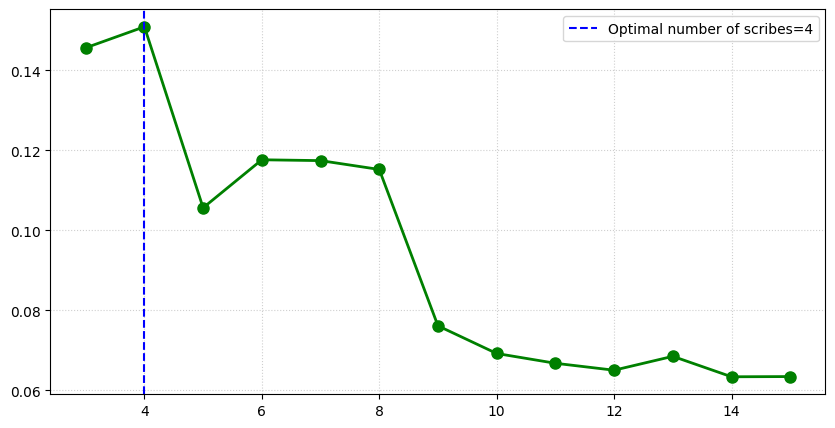

2. Defining the 4 Computational Scribes...
   ...Aligning clusters sequentially to Olszowy-Schlanger...
   ✅ Alignment Complete. Scribes re-numbered 1..K sequentially.
3. Visualizing Scribes in 3D Space...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning:

Graph is not fully connected, spectral embedding may not work as expected.



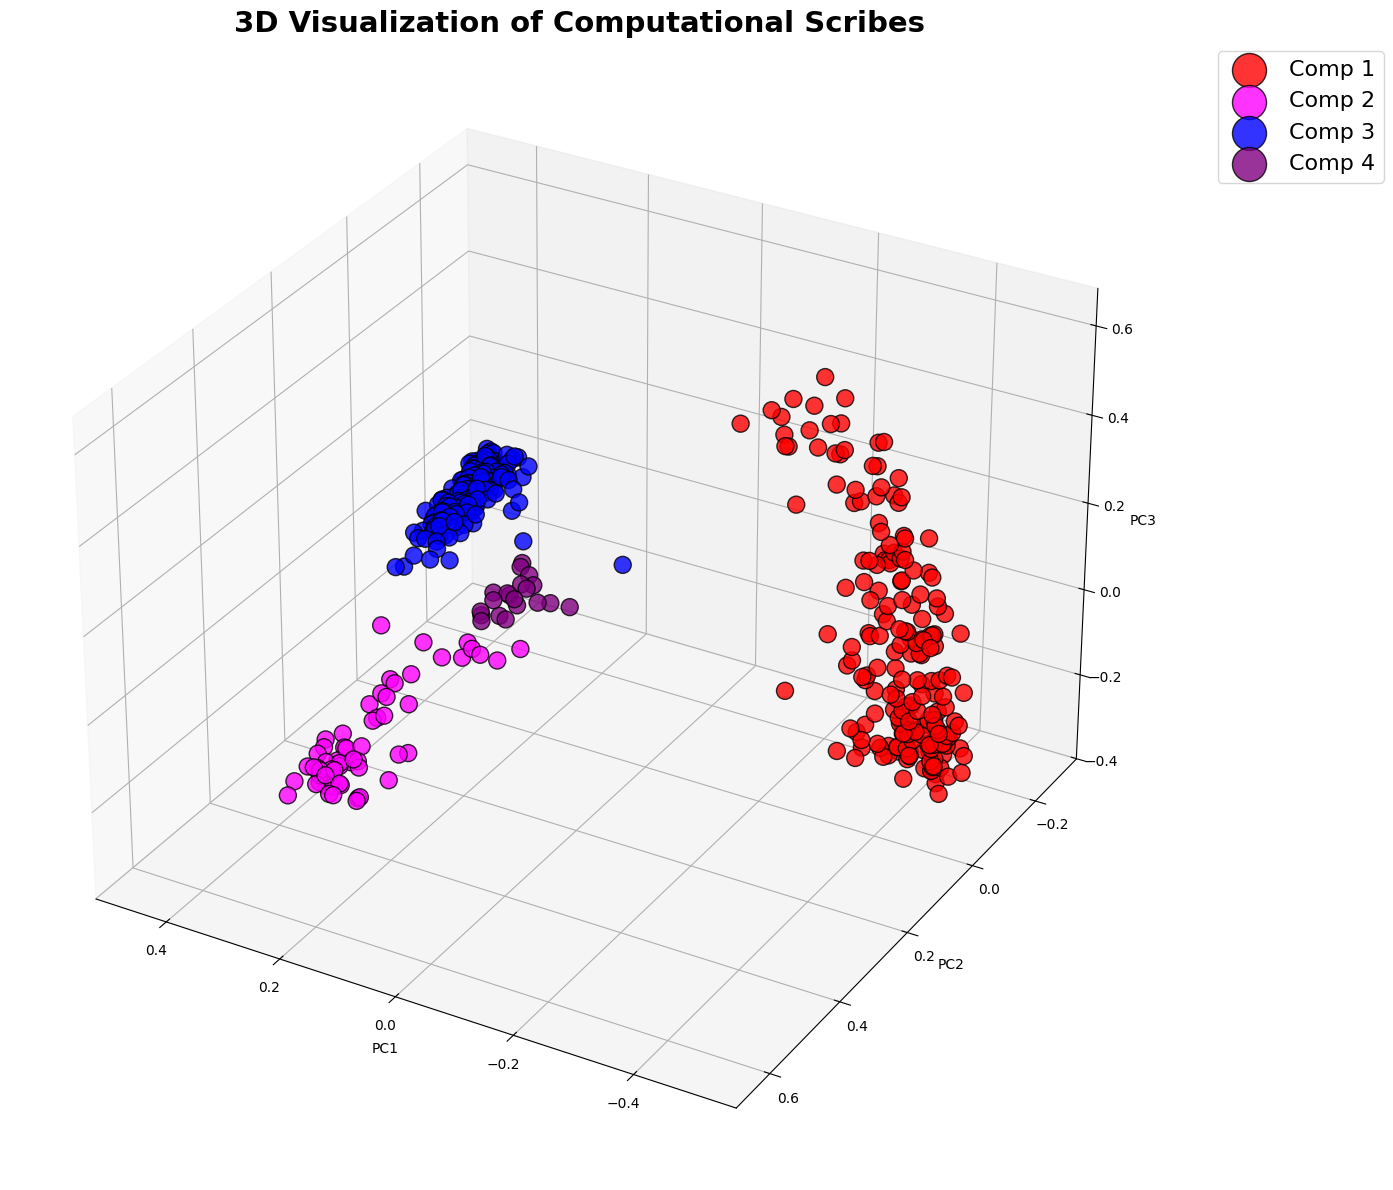


4. Comparison with Historians...

🔹 Computational vs Olszowy-Schlanger:
   ARI Score: 0.984


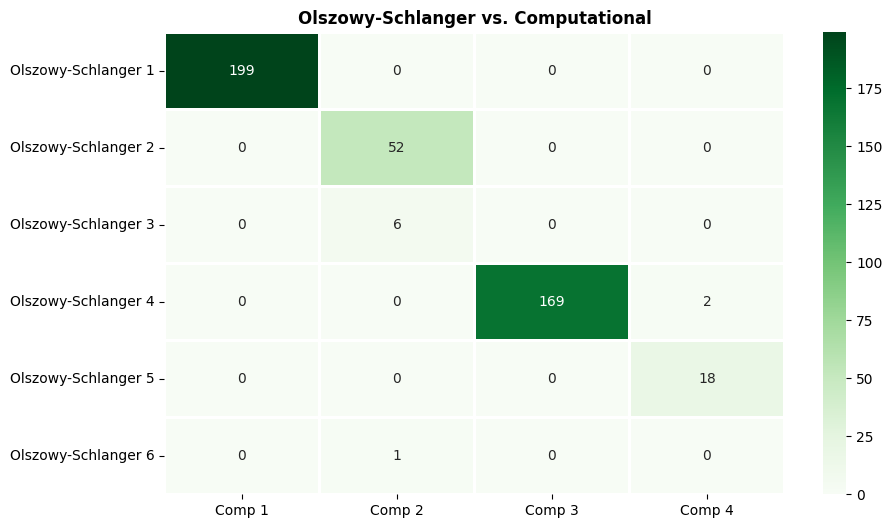


🔹 Computational vs Sfardata:
   ARI Score: 0.716


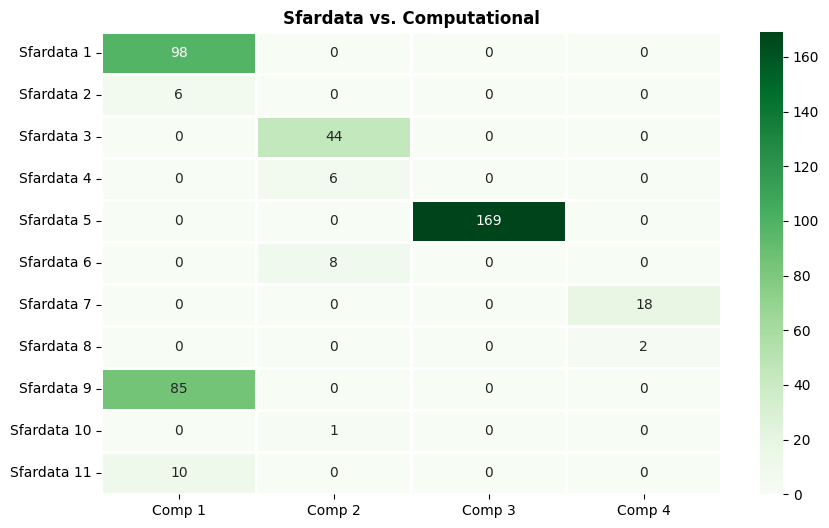

In [68]:
# ==============================================================================
# CELL 36: COMPUTATIONAL SCRIBE DISCOVERY (FIXED SEQUENTIAL ALIGNMENT)
# ==============================================================================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pandas as pd
import numpy as np
import os
import re
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import Normalizer

print("--- Running Automated Computational Scribe Analysis ---")

# 1. PREPARE DATA
norm_data = Normalizer(norm='l2').fit_transform(bovw_matrix)

# 2. SILHOUETTE SCAN
k_range = range(3, 16)
scores = []

print("1. Scanning for optimal scribe count...")
for k in k_range:
    spec = SpectralClustering(
        n_clusters=k,
        affinity='nearest_neighbors',
        n_neighbors=10,
        assign_labels='kmeans',
        random_state=SEED,
        n_jobs=-1
    )
    labels = spec.fit_predict(norm_data)
    score = silhouette_score(norm_data, labels)
    scores.append(score)
    print(f"   k={k}: Silhouette Score = {score:.4f}")

best_score = max(scores)
optimal_k = k_range[scores.index(best_score)]
print(f"\n🏆 WINNER: The dataset naturally separates into {optimal_k} Scribes (Score: {best_score:.4f})")

# Plot Silhouette
plt.figure(figsize=(10, 5))
plt.plot(k_range, scores, 'go-', markersize=8, linewidth=2)
plt.axvline(optimal_k, color='blue', linestyle='--', label=f'Optimal number of scribes={optimal_k}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "silhouette.png"), dpi=300)
plt.show()

# 3. RUN FINAL MODEL
print(f"2. Defining the {optimal_k} Computational Scribes...")
spec_final = SpectralClustering(
    n_clusters=optimal_k,
    affinity='nearest_neighbors',
    n_neighbors=10,
    assign_labels='kmeans',
    random_state=SEED,
    n_jobs=-1
)
raw_labels = spec_final.fit_predict(norm_data)

# ==============================================================================
# ⭐ FIXED: SEQUENTIAL AUTO-ALIGNMENT ⭐
# matches clusters to Olszowy, but ensures 1, 2, 3... are filled sequentially
# ==============================================================================
print("   ...Aligning clusters sequentially to Olszowy-Schlanger...")

# A. Extract ground truth labels
gt_labels = []
for f in image_files:
    folio = extract_folio_side_from_filename(str(f))
    lbl = get_scribe_id_olszowy(folio)
    nums = re.findall(r'\d+', lbl)
    if nums and 'Olszowy' in lbl:
        gt_labels.append(int(nums[0]))
    else:
        gt_labels.append(-1)

# B. Build Cost Matrix
# Rows = Olszowy IDs found, Cols = Cluster IDs
unique_gt = sorted([x for x in set(gt_labels) if x != -1])
# Map real GT IDs to matrix row indices
gt_map = {uid: i for i, uid in enumerate(unique_gt)}

n_rows = len(unique_gt)
n_cols = optimal_k
cost_matrix = np.zeros((n_rows, n_cols))

for i, cluster_id in enumerate(raw_labels):
    gt_id = gt_labels[i]
    if gt_id in gt_map:
        row_idx = gt_map[gt_id]
        cost_matrix[row_idx, cluster_id] += 1

# C. Solve Best Match
row_ind, col_ind = linear_sum_assignment(-cost_matrix)

# D. Sort Matches by Historical Order
# We collect pairs of (Cluster_Index, Matched_Olszowy_Row_Index)
matches = []
for r, c in zip(row_ind, col_ind):
    matches.append((c, r))

# Handle any unmatched clusters (assign them to end)
matched_clusters = set(col_ind)
for c in range(optimal_k):
    if c not in matched_clusters:
        matches.append((c, 999))

# SORT by the matched Olszowy index.
# This ensures Cluster matching Olszowy 1 comes first, Olszowy 2 comes second...
matches.sort(key=lambda x: x[1])

# E. Create Final Mapping (0, 1, 2, 3...)
map_dict = {}
for new_id, (old_id, _) in enumerate(matches):
    map_dict[old_id] = new_id

# Apply
final_labels = np.array([map_dict[x] for x in raw_labels])
print("   ✅ Alignment Complete. Scribes re-numbered 1..K sequentially.")

# ==============================================================================
# 4. VISUALIZE IN 3D
# ==============================================================================
print("3. Visualizing Scribes in 3D Space...")
pca = PCA(n_components=3, random_state=SEED)
pca_res = pca.fit_transform(norm_data)

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Custom Colors
comp_colors_list = ['red', 'magenta', 'blue', 'purple']

# Now we iterate through the NEW sequential IDs (0, 1, 2...)
for cid in range(optimal_k):
    mask = (final_labels == cid)

    # Select color
    if cid < len(comp_colors_list):
        c_val = comp_colors_list[cid]
    else:
        c_val = plt.cm.tab10(cid % 10)

    # Plot
    ax.scatter(pca_res[mask, 0], pca_res[mask, 1], pca_res[mask, 2],
               label=f'Comp {cid+1}', s=150, edgecolors='k', alpha=0.8, c=c_val)

ax.set_title(f"3D Visualization of Computational Scribes", fontweight='bold', fontsize=21)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.view_init(elev=30, azim=120)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=16,markerscale=2.0)
plt.tight_layout()
save_path_3d_sf = os.path.join(OUTPUT_DIR, "3d_pca_plot_comp.png")
plt.savefig(save_path_3d_sf, dpi=300)
plt.show()

# ==============================================================================
# 5. MEASURE HISTORICAL OVERLAP
# ==============================================================================
print("\n4. Comparison with Historians...")

def compare_results(label_func, label_name):
    true_labels = []
    pred_labels = []

    for i, fpath in enumerate(image_files):
        folio = extract_folio_side_from_filename(str(fpath))
        truth = label_func(folio)
        if truth != 'Unknown':
            true_labels.append(truth)
            pred_labels.append(final_labels[i])

    # Metrics
    ari = adjusted_rand_score(true_labels, pred_labels)

    print(f"\n🔹 Computational vs {label_name}:")
    print(f"   ARI Score: {ari:.3f}")

    # Dataframe
    df_cm = pd.DataFrame({'Historical': true_labels, 'Computational': pred_labels})
    ct = pd.crosstab(df_cm['Historical'], df_cm['Computational'])

    # --- SORT ROWS (Historical) NUMERICALLY ---
    def sort_key(s):
        nums = re.findall(r'\d+', str(s))
        return int(nums[0]) if nums else 999
    sorted_index = sorted(ct.index, key=sort_key)
    ct = ct.reindex(sorted_index)

    # --- SORT COLS (Computational) ---
    # They are already 0, 1, 2... but ensuring proper display
    sorted_cols = sorted(ct.columns)
    ct = ct[sorted_cols]

    # Update Column Names (0 -> Comp 1)
    ct.columns = [f"Comp {c+1}" for c in ct.columns]

    # Plot Green Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt='d', cmap='Greens', linewidths=1)

    plt.ylabel('')
    plt.title(f"{label_name} vs. Computational", fontweight='bold')
    save_path_3d_sf = os.path.join(OUTPUT_DIR, f"{label_name}_computational.png")
    plt.savefig(save_path_3d_sf, dpi=300, bbox_inches='tight')
    plt.show()

compare_results(get_scribe_id_olszowy, "Olszowy-Schlanger")
compare_results(get_scribe_id_sfardata, "Sfardata")

In [69]:
# ==============================================================================
# CELL: INTERACTIVE 3D VISUALIZATION (Computational) - BIG LEGEND
# ==============================================================================
import plotly.express as px
import pandas as pd
import matplotlib.colors as mcolors
import os

print("--- Generating Interactive 3D Plot for Computational Scribes (Plotly) ---")

# 1. Prepare Data
# Re-run PCA on normalized data just to be safe
norm_data = Normalizer(norm='l2').fit_transform(bovw_matrix)
pca_3d = PCA(n_components=3, random_state=SEED)
pca_res_3d = pca_3d.fit_transform(norm_data)

# 2. Build DataFrame using 'final_labels' from the previous cell
data_rows = []

# Ensure final_labels exists (from the Spectral Clustering cell)
if 'final_labels' not in globals():
    raise ValueError("❌ 'final_labels' not found. Please run the Computational Scribe Discovery cell first.")

for i, fpath in enumerate(image_files):
    folio = extract_folio_side_from_filename(str(fpath))

    # Convert integer label (0, 1, 2) to String "Comp 1", "Comp 2"...
    cluster_id = final_labels[i]
    scribe_id = f"Comp {cluster_id + 1}"

    data_rows.append({
        'PC1': pca_res_3d[i, 0],
        'PC2': pca_res_3d[i, 1],
        'PC3': pca_res_3d[i, 2],
        'Scribe': scribe_id,
        'Folio': folio,
        'sort_val': cluster_id + 1 # Helper for sorting
    })

df_3d_comp = pd.DataFrame(data_rows)
df_3d_comp = df_3d_comp.sort_values(by=['sort_val', 'Folio'])

# 3. Map Colors (Specific Request)
color_request = ['red', 'magenta', 'blue', 'purple']
plotly_color_map = {}

unique_scribes = sorted(df_3d_comp['Scribe'].unique(), key=lambda x: int(x.split()[-1]))

for i, scribe_name in enumerate(unique_scribes):
    # Use requested colors for first 4, fallback to Plotly defaults for others
    if i < len(color_request):
        plotly_color_map[scribe_name] = color_request[i]
    else:
        # Fallback for Comp 5+ (if they exist)
        plotly_color_map[scribe_name] = px.colors.qualitative.Plotly[i % 10]

# 4. Generate Plot
fig = px.scatter_3d(
    df_3d_comp,
    x='PC1', y='PC2', z='PC3',
    color='Scribe',
    color_discrete_map=plotly_color_map,
    hover_name='Folio',
    title="Interactive 3D Space: Computational Scribes",
    opacity=0.8,

    # Hide coordinates, keep Scribe name
    hover_data={
        'PC1': False,
        'PC2': False,
        'PC3': False,
        'Scribe': True,
        'sort_val': False
    }
)

# 5. Styling (Updated with Big Legend)
fig.update_traces(marker=dict(size=6, line=dict(width=1, color='DarkSlateGrey')))

fig.update_layout(
    width=1200,
    height=900,
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3',
        bgcolor='white'
    ),
    # --- LEGEND STYLING HERE ---
    legend=dict(
        title_font_family="Arial",
        font=dict(size=20),   # Legend Text Size
        itemsizing='constant' # Makes legend dots bigger/consistent
    ),
    legend_title=dict(
        text='Scribe',
        font=dict(size=22)    # Legend Title Size
    )
)

# 6. Save and Show
output_html = os.path.join(OUTPUT_DIR, "interactive_3d_computational.html")
fig.write_html(output_html)
print(f"✅ Interactive plot saved to: {output_html}")

fig.show()

--- Generating Interactive 3D Plot for Computational Scribes (Plotly) ---
✅ Interactive plot saved to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/interactive_3d_computational.html


--- Generating Scribe Barcodes ---


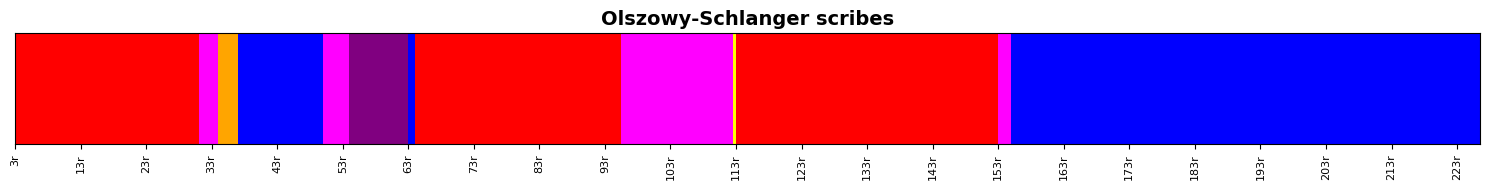

✅ Saved Olszowy-Schlanger barcode to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/barcode_olszowy.png


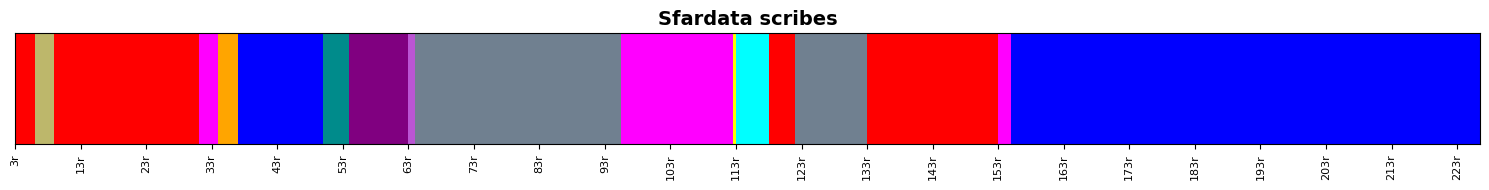

✅ Saved Sfardata barcode to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/barcode_sfardata.png


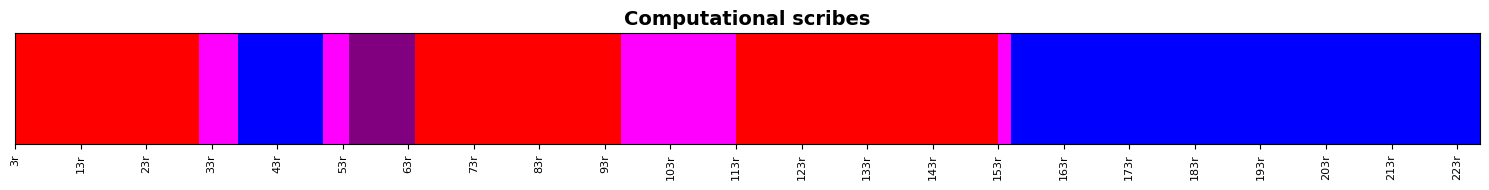

✅ Saved Computational barcode to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/barcode_computational.png


In [70]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
import re

# ==============================================================================
# CELL: SCRIBE BARCODE VISUALIZATION
# ==============================================================================

print("--- Generating Scribe Barcodes ---")

def generate_barcode(label_type, label_func, color_map, filename_suffix):
    # 1. Collect Data in Order
    # We must ensure files are sorted by folio number (1r, 1v, 2r...)

    # Extract numerical folio for sorting
    def sort_key(fpath):
        folio_str = extract_folio_side_from_filename(str(fpath))
        num = int(''.join(filter(str.isdigit, folio_str))) if ''.join(filter(str.isdigit, folio_str)) else 0
        side = 0 if 'r' in folio_str else 1
        return num * 10 + side

    sorted_files = sorted(image_files, key=sort_key)

    # 2. Extract Colors for the Barcode
    barcode_colors = []

    for fpath in sorted_files:
        folio = extract_folio_side_from_filename(str(fpath))

        # Get Scribe ID (e.g., "Comp 1" or "Sfardata 3")
        if label_type == "Computational":
            # For computational, we need to map the index back to the ID string
            # We assume 'final_labels' aligns with 'image_files' (which might not be sorted by folio yet)
            # So we map file -> index -> label -> color

            # Find original index of this file in the 'image_files' list
            # (Note: This is slow but safe for small datasets)
            orig_idx = image_files.index(fpath)
            cluster_id = final_labels[orig_idx]
            scribe_id = f"Comp {cluster_id + 1}"
        else:
            scribe_id = label_func(folio)

        # Get Color
        if scribe_id in color_map:
            barcode_colors.append(color_map[scribe_id])
        else:
            barcode_colors.append('lightgray') # Unknown/Missing

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(15, 2)) # Wide and short

    # Create the bars
    # We plot a vertical line of width 1 for every page
    for i, color in enumerate(barcode_colors):
        ax.add_patch(
            patches.Rectangle(
                (i, 0),   # (x, y)
                1,        # width
                1,        # height
                facecolor=color,
                edgecolor='none'
            )
        )

    # Styling
    ax.set_xlim(0, len(barcode_colors))
    ax.set_ylim(0, 1)
    ax.set_yticks([]) # Hide Y axis

    # Add Folio ticks roughly every 20 pages
    tick_locs = list(range(0, len(barcode_colors), 20))
    tick_labels = [extract_folio_side_from_filename(str(sorted_files[i])) for i in tick_locs]
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=8)

    ax.set_title(f"{label_type} scribes", fontweight='bold', fontsize=14)
    ax.set_xlabel("")

    # Save
    save_path = os.path.join(OUTPUT_DIR, f"barcode_{filename_suffix}.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"✅ Saved {label_type} barcode to: {save_path}")

# --- 1. Olszowy-Schlanger Barcode ---
generate_barcode(
    "Olszowy-Schlanger",
    get_scribe_id_olszowy,
    SCRIBE_COLORS,
    "olszowy"
)

# --- 2. Sfardata Barcode ---
generate_barcode(
    "Sfardata",
    get_scribe_id_sfardata,
    SCRIBE_COLORS,
    "sfardata"
)

# --- 3. Computational Barcode ---
# Define specific map for computational
comp_color_map = {
    'Comp 1': 'red',
    'Comp 2': 'magenta',
    'Comp 3': 'blue',
    'Comp 4': 'purple',
    # Fallbacks if k > 4
    'Comp 5': 'orange', 'Comp 6': 'cyan'
}

generate_barcode(
    "Computational",
    None, # Not used for Comp logic inside function
    comp_color_map,
    "computational"
)

--- Generating Scribe Barcodes with Labels ---


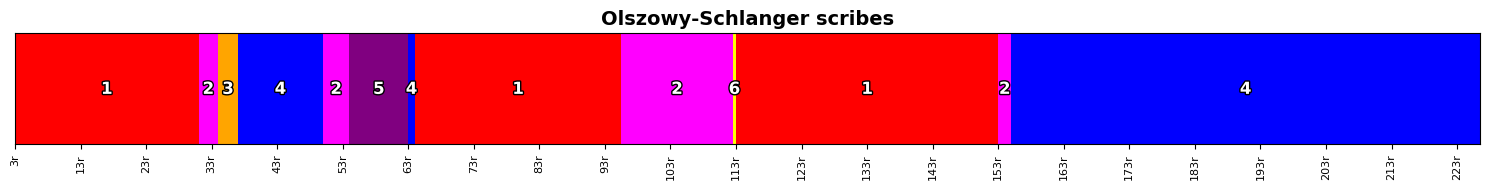

✅ Saved Olszowy-Schlanger barcode to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/barcode_olszowy.png


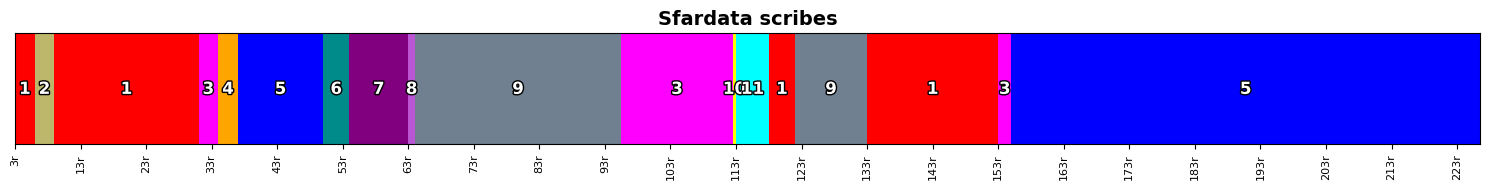

✅ Saved Sfardata barcode to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/barcode_sfardata.png


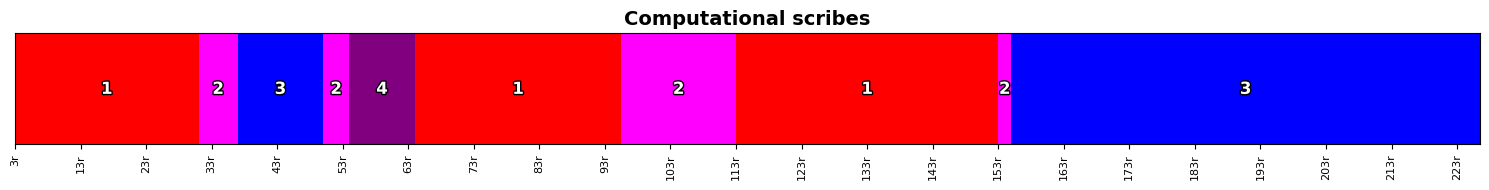

✅ Saved Computational barcode to: /content/drive/MyDrive/Colab Notebooks/hsd_14_02_2025/hsd_01_12_2025/barcode_computational.png


In [71]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
import re
import itertools  # Added for grouping sequential data

# ==============================================================================
# CELL: SCRIBE BARCODE VISUALIZATION (WITH LABELS)
# ==============================================================================

print("--- Generating Scribe Barcodes with Labels ---")

def generate_barcode(label_type, label_func, color_map, filename_suffix):
    # 1. Collect Data in Order
    def sort_key(fpath):
        folio_str = extract_folio_side_from_filename(str(fpath))
        num = int(''.join(filter(str.isdigit, folio_str))) if ''.join(filter(str.isdigit, folio_str)) else 0
        side = 0 if 'r' in folio_str else 1
        return num * 10 + side

    sorted_files = sorted(image_files, key=sort_key)

    # 2. Extract Colors AND IDs for the Barcode
    barcode_colors = []
    barcode_ids = []  # Store IDs to find blocks later

    for fpath in sorted_files:
        folio = extract_folio_side_from_filename(str(fpath))

        # Get Scribe ID
        if label_type == "Computational":
            orig_idx = image_files.index(fpath)
            cluster_id = final_labels[orig_idx]
            scribe_id = f"Comp {cluster_id + 1}"
        else:
            scribe_id = label_func(folio)

        # Store ID
        barcode_ids.append(scribe_id)

        # Get Color
        if scribe_id in color_map:
            barcode_colors.append(color_map[scribe_id])
        else:
            barcode_colors.append('lightgray') # Unknown/Missing

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(15, 2))

    # Create the bars
    for i, color in enumerate(barcode_colors):
        ax.add_patch(
            patches.Rectangle(
                (i, 0),   # (x, y)
                1,        # width
                1,        # height
                facecolor=color,
                edgecolor='none'
            )
        )

    # --- NEW: Add Scribe Numbers on Color Parts ---
    current_idx = 0
    # Group contiguous blocks of the same scribe
    for scribe_id, group in itertools.groupby(barcode_ids):
        # Length of this contiguous block
        block_len = len(list(group))

        # Extract number (e.g. "Olszowy 1" -> "1")
        nums = re.findall(r'\d+', str(scribe_id))

        # Only label if we found a number and it's not "Unknown"
        if nums and scribe_id != 'Unknown':
            num_str = nums[0]

            # Calculate center of the block
            center_x = current_idx + (block_len / 2)

            # Place text (only if block is wide enough to be readable, e.g. > 2 pages)
            # You can remove the 'if block_len > 2' check if you want every single sliver labeled
            if block_len >= 1:
                ax.text(
                    center_x, 0.5, num_str,
                    ha='center', va='center',
                    color='white',
                    fontweight='bold',
                    fontsize=12,
                    path_effects=[import_patheffects()] # Helper to add outline for visibility
                )

        current_idx += block_len
    # ----------------------------------------------

    # Styling
    ax.set_xlim(0, len(barcode_colors))
    ax.set_ylim(0, 1)
    ax.set_yticks([])

    # Add Folio ticks
    tick_locs = list(range(0, len(barcode_colors), 20))
    tick_labels = [extract_folio_side_from_filename(str(sorted_files[i])) for i in tick_locs]
    ax.set_xticks(tick_locs)
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=8)

    ax.set_title(f"{label_type} scribes", fontweight='bold', fontsize=14)
    ax.set_xlabel("")

    # Save
    save_path = os.path.join(OUTPUT_DIR, f"barcode_{filename_suffix}.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"✅ Saved {label_type} barcode to: {save_path}")

# Helper for Text Outline (makes white text readable on yellow/gold)
def import_patheffects():
    import matplotlib.patheffects as path_effects
    return path_effects.withStroke(linewidth=2, foreground='black')

# --- 1. Olszowy-Schlanger Barcode ---
generate_barcode(
    "Olszowy-Schlanger",
    get_scribe_id_olszowy,
    SCRIBE_COLORS,
    "olszowy"
)

# --- 2. Sfardata Barcode ---
generate_barcode(
    "Sfardata",
    get_scribe_id_sfardata,
    SCRIBE_COLORS,
    "sfardata"
)

# --- 3. Computational Barcode ---
comp_color_map = {
    'Comp 1': 'red',
    'Comp 2': 'magenta',
    'Comp 3': 'blue',
    'Comp 4': 'purple',
    'Comp 5': 'orange', 'Comp 6': 'cyan'
}

generate_barcode(
    "Computational",
    None,
    comp_color_map,
    "computational"
)